##IMPORTANTE: Importaciones necesarias para que todo funcione correctamente. Incluye pandas numpy matplotlib seaborn sklearn impute preprocessing compose y pipelines.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import  SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


# 1. CARGA Y EXPLORACION INICIAL

1.1 Cargar dataset:

In [ ]:
#CARGA DEL DATASET PARA DESPUES REALIZAR EL RESPECTIVO ANALISIS

df = pd.read_csv("Food_Preference(1).csv")
df.head()

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,2019/05/07 2:59:13 PM GMT+8,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,2019/05/07 3:00:05 PM GMT+8,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,2019/05/07 3:00:11 PM GMT+8,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


creamos el dataframe

In [ ]:
# Guardar el DataFrame original en un nuevo archivo CSV
data_normal = df.copy()
data_normal.to_csv('Food_Preference_sinProcesar.csv', index=False)
#verificacion de que el archivo se creo correctamente
if data_normal is not None:
    print('El DataFrame ha sido guardado exitosamente.')
elif data_normal.empty:
    print('el DataFrame esta vacio.')
else:
    print('No se pudo guardar el DataFrame.')

data_normal.head()

El DataFrame Food_Preference_Processed.csv ha sido guardado exitosamente.


,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,2019/05/07 2:59:13 PM GMT+8,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,2019/05/07 3:00:05 PM GMT+8,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,2019/05/07 3:00:11 PM GMT+8,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


1.2 Analizar los datos:

In [ ]:
#OBTENER INFORMACION DE LOS TIPOS DE DATOS QUE MANEJA EL ARCHIVO (TAMBIEN SE PUEDE OBSERVAR SI ESQUE HAY DATOS FALTANTES)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       290 non-null    object 
 1   Participant_ID  290 non-null    object 
 2   Gender          284 non-null    object 
 3   Nationality     290 non-null    object 
 4   Age             288 non-null    float64
 5   Food            290 non-null    object 
 6   Juice           290 non-null    object 
 7   Dessert         290 non-null    object 
dtypes: float64(1), object(7)
memory usage: 18.3+ KB


In [ ]:
# UN DESCRIBE TE DA LA ESTADISTICA DESCRIPTICA DE LAS VARIABLES NUMERICAS , EN ESTE CASO 'AGE'
df.describe()

,Age
count,288.000000
mean,31.625000
std,20.843326
min,-47.000000
25%,24.000000
50%,28.000000
75%,37.000000
max,263.000000


1.3 Identificar la existencia de valores faltantes (nulos):

In [ ]:
#INDENIFICA SI HAY VALORES NULOS Y EN QUE COLUMNAS SE ENCUENTRAN
df.isna().sum()

,0
Timestamp,0
Participant_ID,0
Gender,6
Nationality,0
Age,2
Food,0
Juice,0
Dessert,0


1.4 Determinar la existencia de registros duplicados:

In [ ]:
#INDENTIFICA SI HAY VALORES DUPLICADOS
df.duplicated().sum()

np.int64(2)

1.5 Detectar outliers (valores atípicos):

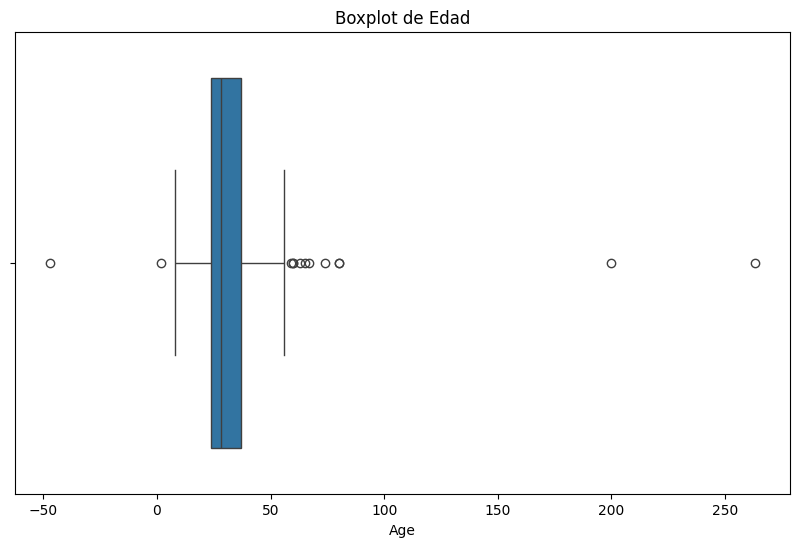

In [ ]:
#DETECCION DE POSIBLES OUTLIERS EN LA COLUMNA AGE(EDAD) YA QUE ESTA ES LA UNICA NUMERICA
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Age'])
plt.title('Boxplot de Edad')
plt.show()

Se puede apreciar errores en la edad como: usuarios con edades negativas, muy pequeñas o excesivamente grandes.

1.6 Identificar errores tipográficos en variables categóricas:

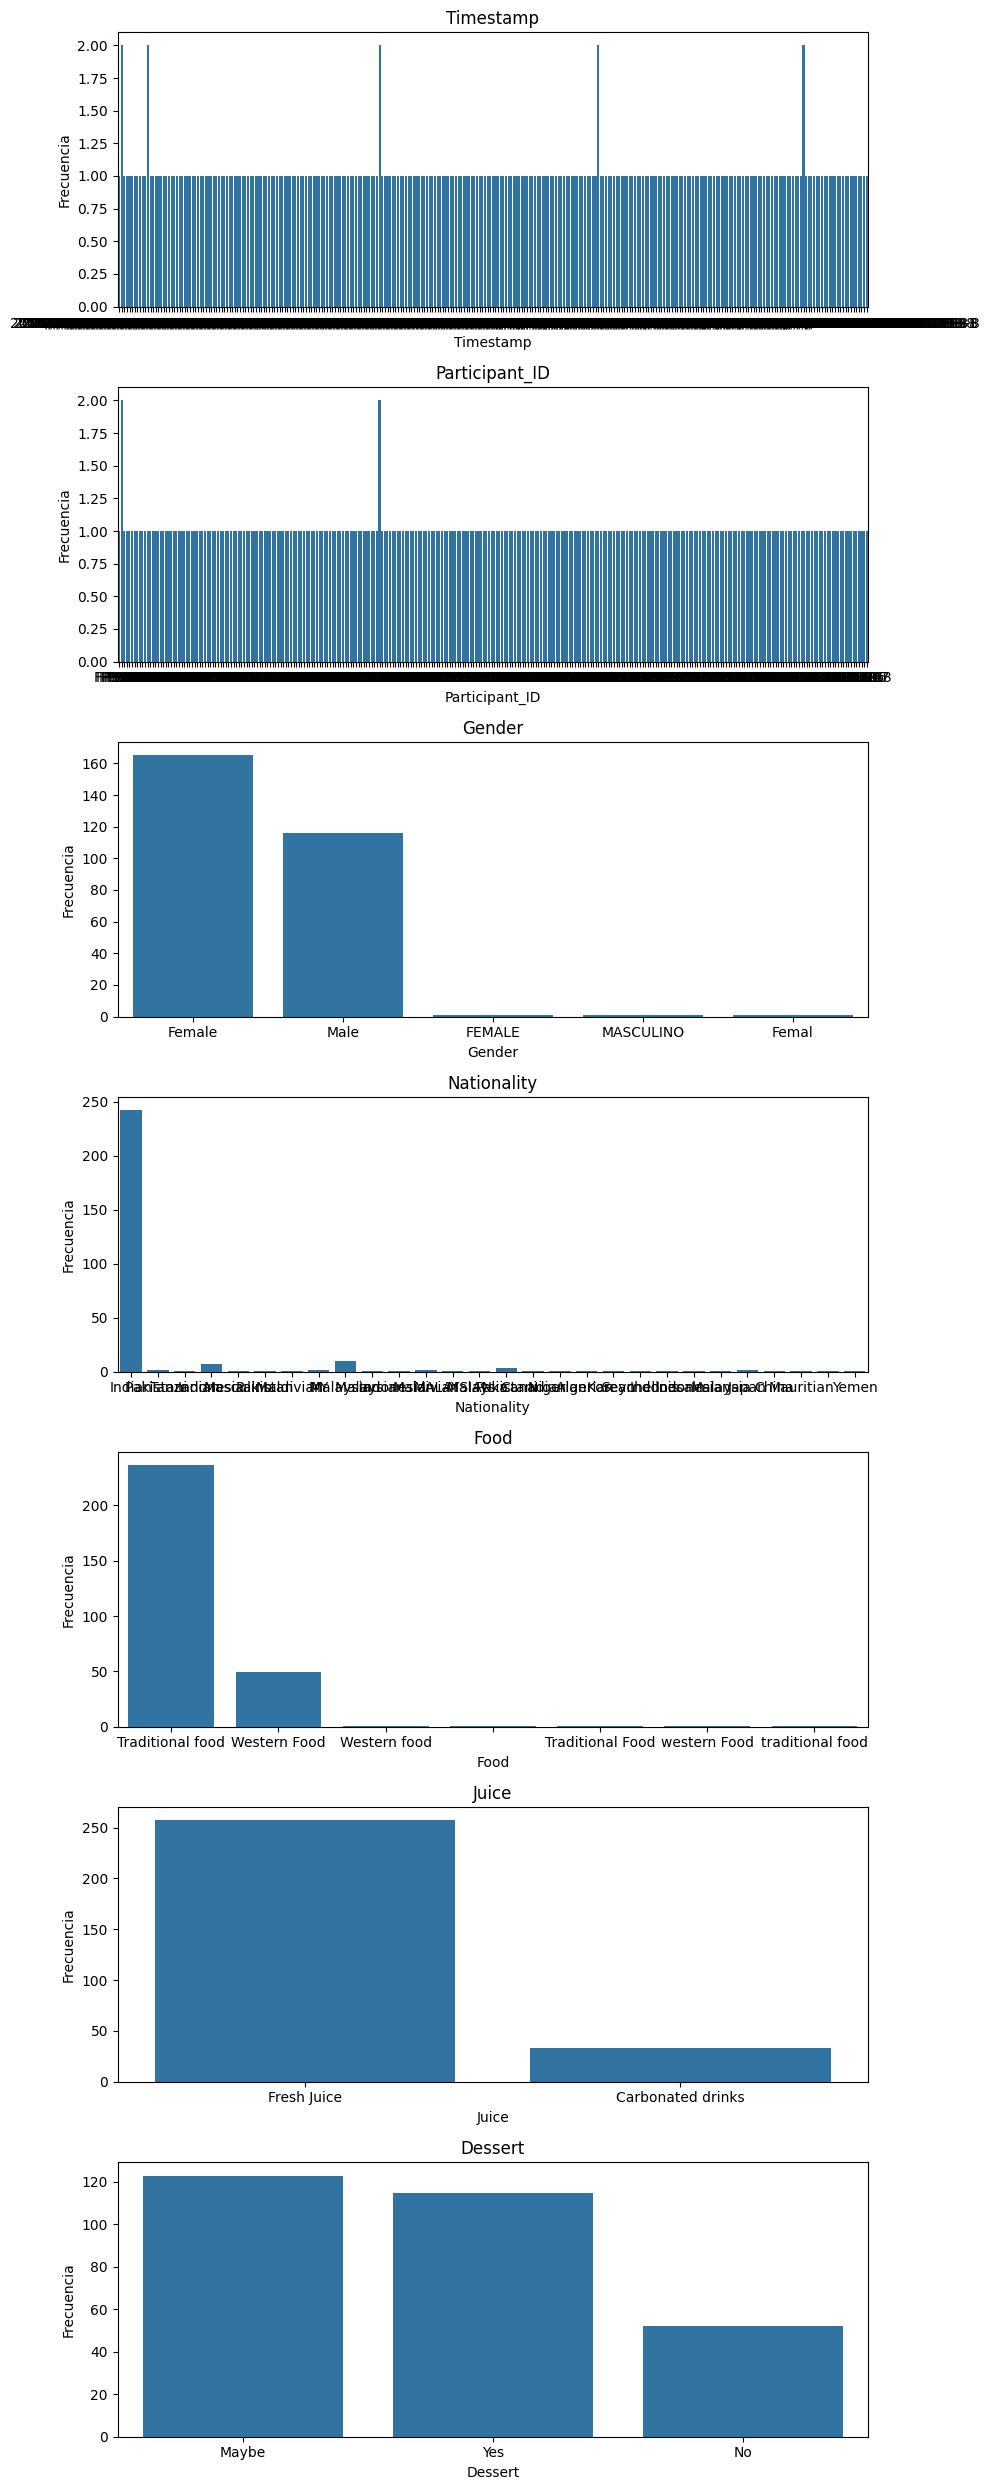

In [ ]:
#grafico de boxplot para identificar si hay errores tipograficos en las variables categoricas
categoricas = df.select_dtypes(include="object").columns
categoricas

fig, axes = plt.subplots(nrows=len(categoricas), ncols=1, figsize=(10, 25))

for i, col in enumerate(categoricas):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se detectan multiples errores en las variables categoricas siguientes:

Food: Tiene errores tipograficos lo que causa muchas columnas.

Nationality: Tiene errores tipograficos excesivos lo que causa muchas columnas para un solo pais, tambien tiene valores erroneos o sin nombre.

Gender: Tiene errores tipograficos lo que causa muchas columnas.

Participant_ID: tiene valor duplicado-

Timestamp: tiene valor duplicado.



In [ ]:
#ESTAMOS IDENFICICANDO SI ESQUE HAY ERRORES TIPOGRAFICOS EN LAS VARIABLES CATEGORICAS
desert = df['Dessert'].value_counts().sort_index()
desert

,count
Dessert,
Maybe,123
No,52
Yes,115


In [ ]:
jugo = df['Juice'].value_counts().sort_index()
jugo

,count
Juice,
Carbonated drinks,33
Fresh Juice,257


In [ ]:
genero = df['Gender'].value_counts().sort_index()
genero

,count
Gender,
FEMALE,1
Femal,1
Female,165
MASCULINO,1
Male,116


In [ ]:
nacionalidades = df['Nationality'].value_counts().sort_index()
nacionalidades

,count
Nationality,
,1
Algerian,1
Canadian,1
China,1
Indian,242
Indonesain,1
Indonesia,7
Indonesian,1
Indonesian,1


In [ ]:
comida = df['Food'].value_counts().sort_index()
comida

,count
Food,
,1
Traditional Food,1
Traditional food,236
Western Food,49
Western food,1
traditional food,1
western Food,1


# Manipulación de datos:

2.1 Selección de columnas relevantes:

In [ ]:
#aqui se selecionan las columnas que son releventaste y se quitan las que no se utilizaran o no tendran importancia en el futuro (Timestamp, Participant_ID)
df_2 = df.drop(columns=['Timestamp', 'Participant_ID'])
df_2.head()

,Gender,Nationality,Age,Food,Juice,Dessert
0,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


2.2 Filtrado de filas:

2.3 Joins, merges y concatenaciones simples:

# Limpieza:

3.1 Tratar valores faltantes (eliminar o imputar):

In [ ]:
#aplicamos moda e imputamos para Gender
moda = df_2['Gender'].mode()[0]
print(f'valores faltantes: {df_2["Gender"].isna().sum()}')
df_2['Gender'].fillna(moda, inplace=True)
print(f'valores faltantes(nuevo): {df_2["Gender"].isna().sum()}')

valores faltantes: 6
valores faltantes(nuevo): 0


/tmp/ipykernel_7755/2702157595.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_2['Gender'].fillna(moda, inplace=True)


In [ ]:
#aplicamos la mediana para imputar la edad
imputar = SimpleImputer(strategy='median')
print(f"mediana inicial : {df_2['Age'].median()}")
print(f"valores faltantes: {df_2['Age'].isna().sum()}")
df_2['Age'] = imputar.fit_transform(df_2[['Age']])
print(f"mediana final : {df_2['Age'].median()}")
print(f"valores faltantes: {df_2['Age'].isna().sum()}")

mediana inicial : 28.0
valores faltantes: 2
mediana final : 28.0
valores faltantes: 0


3.2 Eliminar registros duplicados:

In [ ]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df_2.shape}')
df_2.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df_2.shape}')

Tamaño del set antes de eliminar las filas repetidas: (290, 6)
Tamaño del set después de eliminar las filas repetidas: (202, 6)


3.3 Tratar los outliers identificados:

/tmp/ipykernel_7755/1257861711.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_2 = df_2[(df['Age'] > 5) & (df_2['Age'] < 100)]


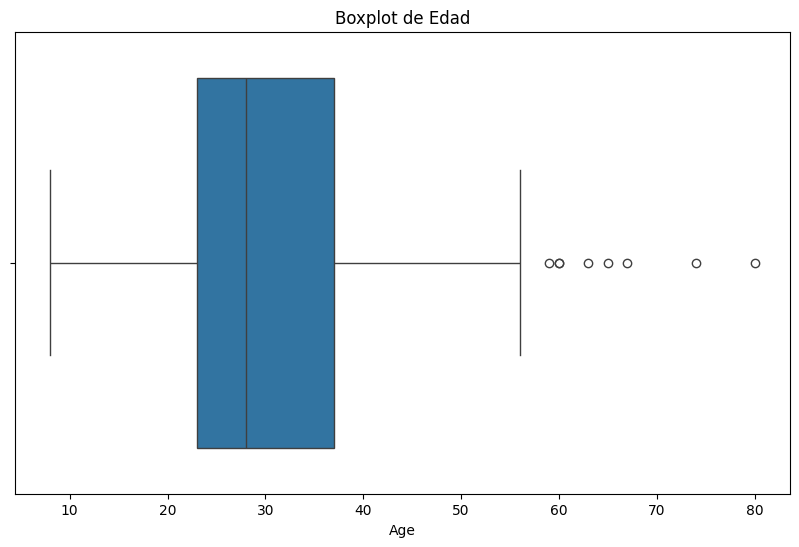

In [ ]:
#tratamos los outliers dandole un rango de edad entre 5 hasta 99
df_2 = df_2[(df['Age'] > 5) & (df_2['Age'] < 100)]
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_2['Age'])
plt.title('Boxplot de Edad')
plt.show()

Aun teniendo outliers se han decidido dejar, ya que es posible que una persona de 80 años pase a comer.

3.4 Unificar mayúsculas/minúsculas en columnas de texto:

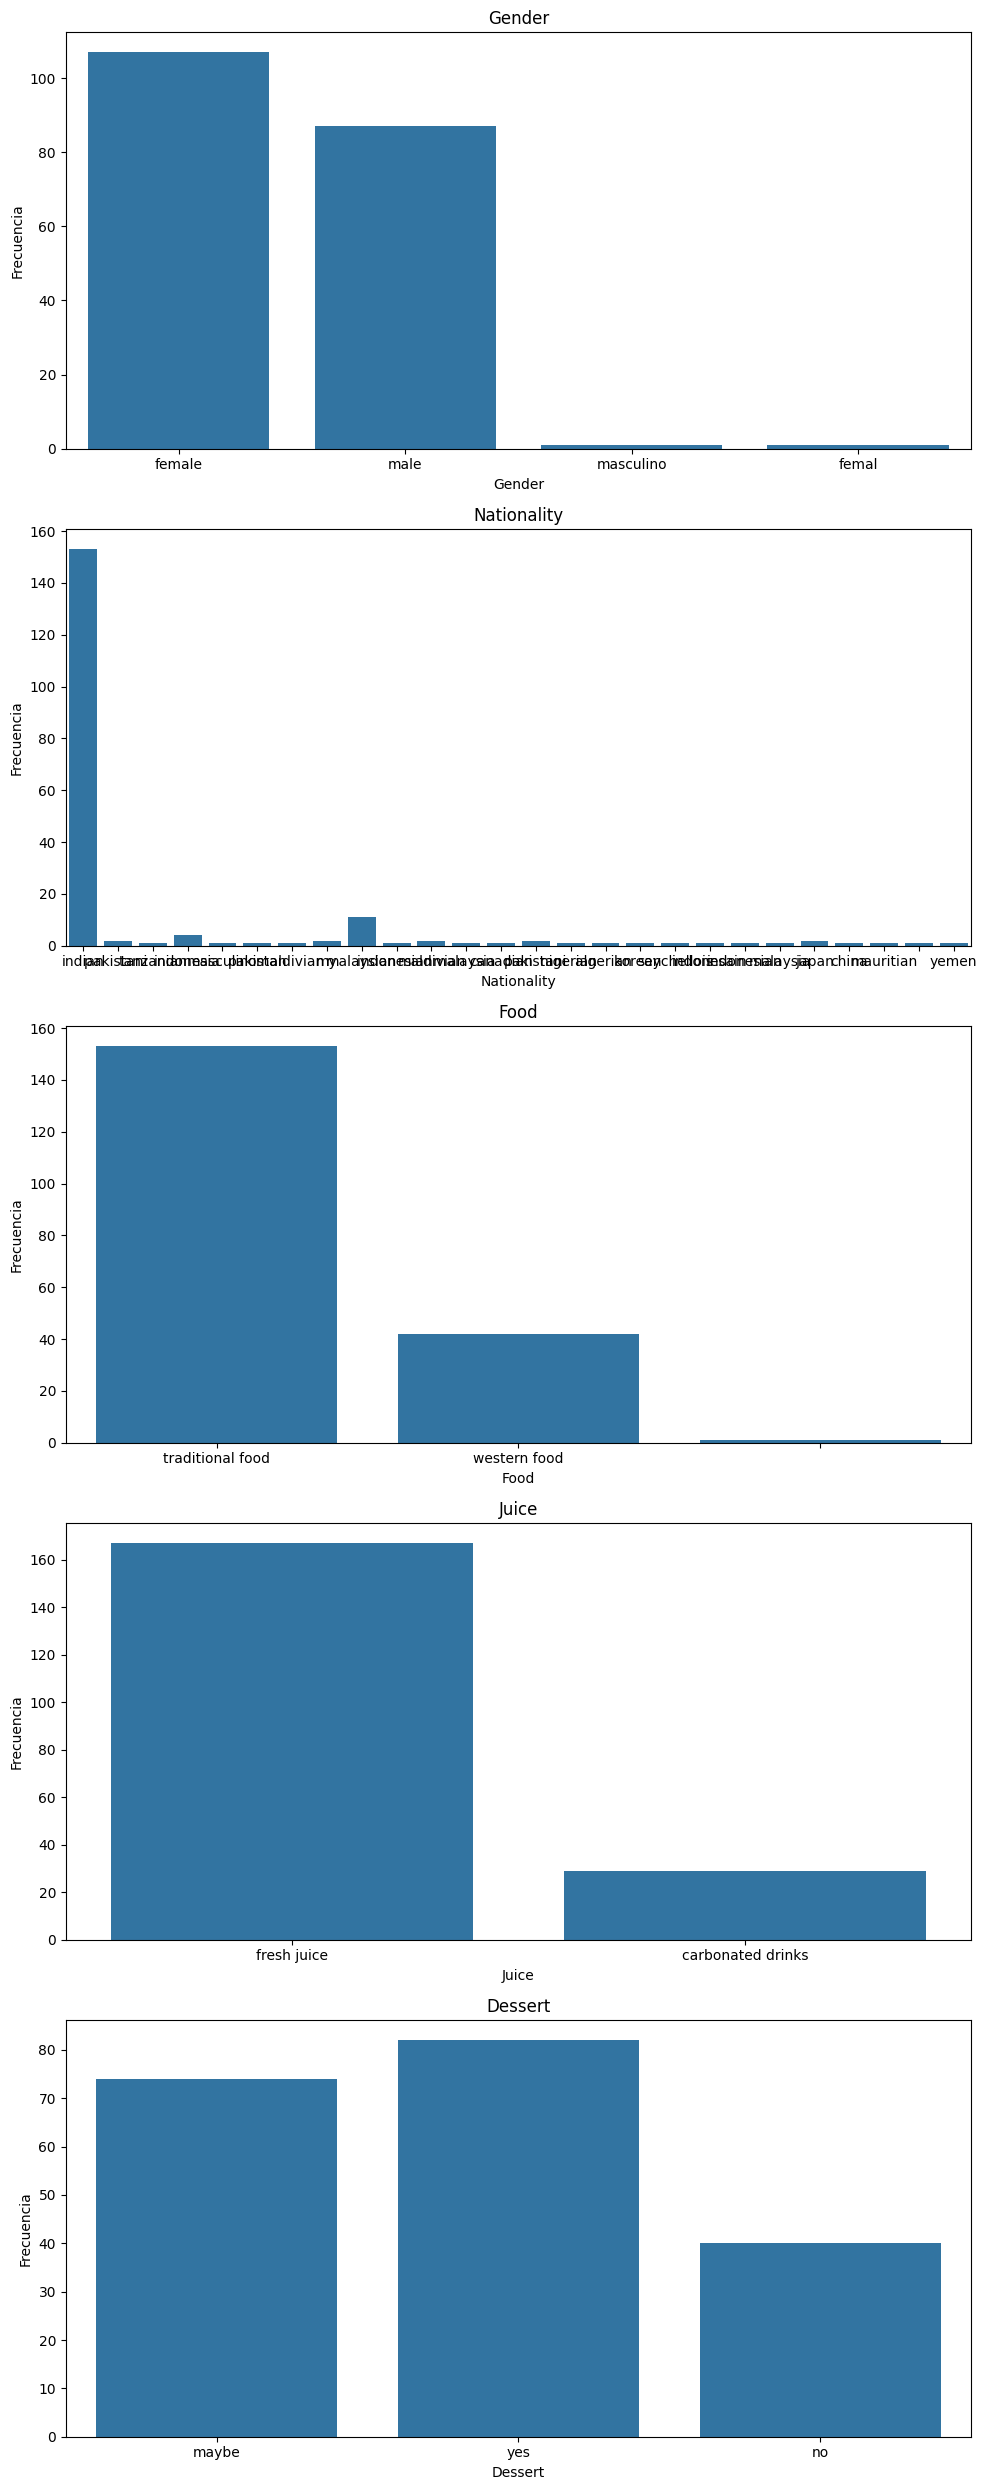

In [ ]:
#Se unifican primero las fuentes del texto a minuscula para mayor eficiencia.
categoricas = df_2.select_dtypes(include='object').columns

for column in df_2.columns:
    # Representar en minúsculas sólo si la columna es categórica
    if column in categoricas:
        df_2[column] = df_2[column].str.lower()

fig, axes = plt.subplots(nrows=len(categoricas), ncols=1, figsize=(10, 25))

for i, col in enumerate(categoricas):
    sns.countplot(x=col, data=df_2, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

3.5 Corregir errores tipográficos en variables categóricas.

In [ ]:
#Reemplazamos los errores Femal FEMALE MASCULINO y Masculino a Male y Female
print(df_2['Gender'].unique())
df_2['Gender'] = df_2['Gender'].replace({'femal': 'Female', 'male': 'Male'})
df_2['Gender'] = df_2['Gender'].replace({'female': 'Female', 'masculino': 'Male'})
print(df_2['Gender'].unique())


['female' 'male' 'masculino' 'femal']
['Female' 'Male']


/tmp/ipykernel_7755/2447497121.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=30)


[Text(0, 0, 'Female'), Text(1, 0, 'Male')]

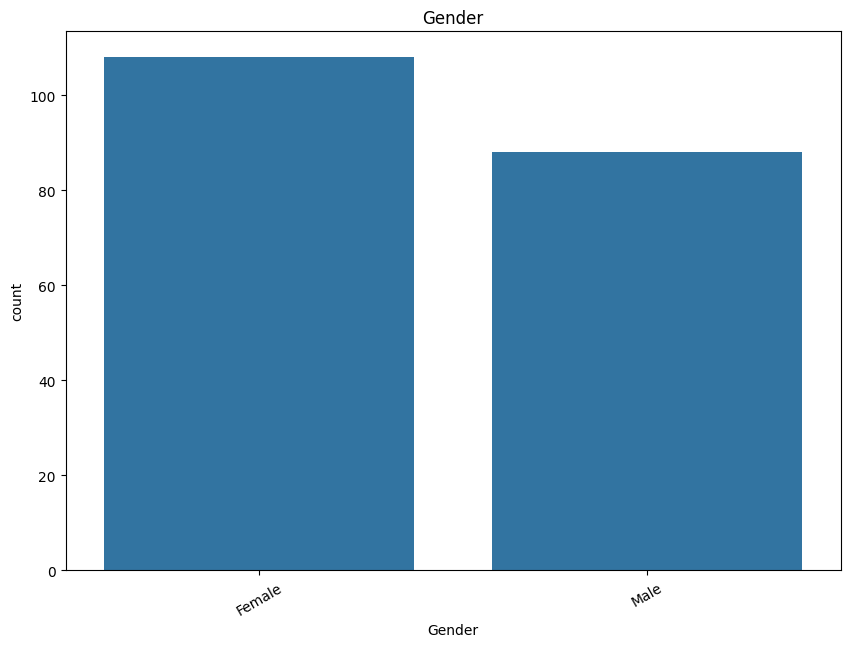

In [ ]:
cols_cat = ['Gender']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,7))
fig.subplots_adjust(hspace=1)
sns.countplot(x=cols_cat[0], data=df_2, ax=ax)
ax.set_title(cols_cat[0])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [ ]:
# se unifican los valores de los paises con errores tipograficos
df_2['Nationality'] = df_2['Nationality'].replace({'indonesia': 'indonesian', 'indonesian ': 'indonesian','indonesain': 'indonesian'})
df_2['Nationality'] = df_2['Nationality'].replace({'malasya': 'malaysian' , 'malasya ':'malaysian', 'malaysia ':'malaysian', 'malaysian ': 'malaysian' , 'malaysia': 'malaysian', 'my': 'malaysian' })
df_2['Nationality'] = df_2['Nationality'].replace({'pakistani':'pakistan' , 'pakistani ':'pakistan'})
df_2['Nationality'] = df_2['Nationality'].replace({'maldivian ':'maldivian'})



In [ ]:
#eliminamos los valores 'masculino' y ' ' de columna nacionalidades
df_2 = df_2[df_2['Nationality'] != 'masculino']
df_2 = df_2[df_2['Nationality'] != ' ']

In [ ]:
#se verifica que la columna Nationality ya no contiene errores
nacionalidades = df_2['Nationality'].value_counts().sort_index()
nacionalidades

,count
Nationality,
algerian,1
canadian,1
china,1
indian,153
indonesian,7
japan,2
korean,1
malaysian,15
maldivian,3


/tmp/ipykernel_7755/3920475199.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=30)


[Text(0, 0, 'indian'),
 Text(1, 0, 'pakistan'),
 Text(2, 0, 'tanzanian'),
 Text(3, 0, 'indonesian'),
 Text(4, 0, 'maldivian'),
 Text(5, 0, 'malaysian'),
 Text(6, 0, 'canadian'),
 Text(7, 0, 'nigerian '),
 Text(8, 0, 'algerian '),
 Text(9, 0, 'korean '),
 Text(10, 0, 'seychellois'),
 Text(11, 0, 'japan'),
 Text(12, 0, 'china'),
 Text(13, 0, 'mauritian'),
 Text(14, 0, 'yemen')]

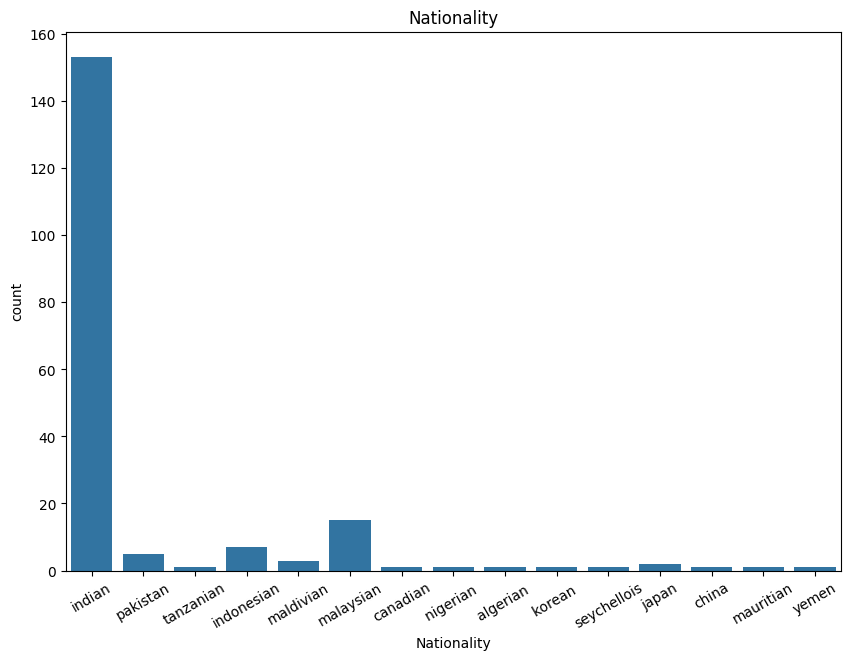

In [ ]:
#grafico para verificar si las nacionalidades estan cambiadas correctamente
cols_cat = ['Nationality']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,7))
fig.subplots_adjust(hspace=1)
sns.countplot(x=cols_cat[0], data=df_2, ax=ax)
ax.set_title(cols_cat[0])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [ ]:
#otra forma de verificar si esta correcto pero menos grafica que la anterior
print(df_2['Nationality'].unique())


['indian' 'pakistan' 'tanzanian' 'indonesian' 'maldivian' 'malaysian'
 'canadian' 'nigerian ' 'algerian ' 'korean ' 'seychellois' 'japan'
 'china' 'mauritian' 'yemen']


In [ ]:
#se elimina el caracter en blanco ya que es solo 1 y no logra afectar a los datos
print(df['Food'].unique())
df = df[df['Food'].str.strip() != '']
print(df['Food'].unique())
print(df['Food'].value_counts())

['Traditional food' 'Western Food' 'Western food' ' ' 'Traditional Food'
 'western Food' 'traditional food']
['Traditional food' 'Western Food' 'Western food' 'Traditional Food'
 'western Food' 'traditional food']
Food
Traditional food    236
Western Food         49
Western food          1
Traditional Food      1
western Food          1
traditional food      1
Name: count, dtype: int64


In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194 entries, 0 to 283
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gender       194 non-null    object 
 1   Nationality  194 non-null    object 
 2   Age          194 non-null    float64
 3   Food         194 non-null    object 
 4   Juice        194 non-null    object 
 5   Dessert      194 non-null    object 
dtypes: float64(1), object(5)
memory usage: 10.6+ KB


# Transformación:

4.1 Crear agregaciones a partir de las variables originales (crear nuevas variables), si corresponde:

In [ ]:
#se crea la columna de Nationality usando el metodo labelencoder para tranformarla a numeros.
df_2['Nationality_encode']= LabelEncoder().fit_transform(df_2['Nationality'])
df_2.head()

,Gender,Nationality,Age,Food,Juice,Dessert,Nationality_encode
0,Female,indian,24.0,traditional food,fresh juice,maybe,3
1,Female,indian,22.0,western food,carbonated drinks,yes,3
3,Male,indian,31.0,western food,fresh juice,maybe,3
4,Female,indian,25.0,traditional food,fresh juice,maybe,3
5,Female,indian,27.0,traditional food,fresh juice,maybe,3


In [ ]:
#Tranformamos las variables categoricas a numericas mediante el metodo OneHotEncoder, Mientras que para variables numericas como age se usa StandarScaler para escalarlas.
pipeline = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(), ['Gender','Food','Juice','Dessert']),
    ('num', StandardScaler(), ['Age'])
])

X_transf = pipeline.fit_transform(df_2)
print(X_transf)

numerica_f = ["Age"]
numerica_t = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categoricas_f = ["Gender","Food", "Juice", "Dessert"]
categoricas_t = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerica_t, numerica_f),
        ("cat", categoricas_t, categoricas_f)
    ]
)

df_processed = preprocessor.fit_transform(df_2)

#

feature_names_out = preprocessor.get_feature_names_out()


df_processed = pd.DataFrame(df_processed, columns=feature_names_out)


categorical_processed_columns = [col for col in feature_names_out if any(cat_feat in col for cat_feat in categoricas_f)]
print(df_processed[categorical_processed_columns])

[[ 1.          0.          0.         ...  0.          0.
  -0.57699559]
 [ 1.          0.          0.         ...  0.          1.
  -0.74319773]
 [ 0.          1.          0.         ...  0.          0.
   0.00471192]
 ...
 [ 0.          1.          0.         ...  0.          1.
  -0.2445913 ]
 [ 0.          1.          0.         ...  0.          1.
  -0.49389452]
 [ 0.          1.          0.         ...  0.          0.
  -0.32769237]]
     cat__Gender_Female  cat__Gender_Male  cat__Food_   \
0                   1.0               0.0          0.0   
1                   1.0               0.0          0.0   
2                   0.0               1.0          0.0   
3                   1.0               0.0          0.0   
4                   1.0               0.0          0.0   
..                  ...               ...          ...   
189                 1.0               0.0          0.0   
190                 0.0               1.0          0.0   
191                 0.0           

In [ ]:
#SE ELIMINAN LAS VARIABLES NUMERICAS Y CATEGORICAS QUE NO ESTAN ENCODE, YA QUE EN EL ARCHIVO TIENEN QUE QUEDAR SOLO LAS QUE ESTAN ENCODE
df_merged= df_2.copy()
df_merged = df_merged.drop(columns=["Nationality"] + numerica_f + categoricas_f)


data_merged = pd.concat([df_merged.reset_index(drop=True), df_processed.reset_index(drop=True)], axis=1)

# display para comprobar si se ven las columnas
display(data_merged.head())

,Nationality_encode,num__Age,cat__Gender_Female,cat__Gender_Male,cat__Food_,cat__Food_traditional food,cat__Food_western food,cat__Juice_carbonated drinks,cat__Juice_fresh juice,cat__Dessert_maybe,cat__Dessert_no,cat__Dessert_yes
0,3,-0.576996,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,3,-0.743198,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,3,0.004712,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,3,-0.493895,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,3,-0.327692,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


## 5. Exportación del Resultado Final

In [ ]:
# Guardar el DataFrame final procesado en un nuevo archivo CSV
data_merged.to_csv('Food_Preference_Processed.csv', index=False)
#verificacion de que el archivo se creo correctamente
if data_merged is not None:
    print('El DataFrame Food_Preference_Processed.csv ha sido guardado exitosamente.')
elif data_merged.empty:
    print('el DataFrame esta vacio.')
else:
    print('No se pudo guardar el DataFrame.')


El DataFrame Food_Preference_Processed.csv ha sido guardado exitosamente.


## 6. Evidencia de la Efectividad de la Limpieza y Transformación

In [ ]:
# Mostrar las primeras filas del DataFrame final para evidenciar la transformación
print('Primeras 5 filas del DataFrame procesado:')
display(data_merged.head())

Primeras 5 filas del DataFrame procesado:


,Nationality_encode,num__Age,cat__Gender_Female,cat__Gender_Male,cat__Food_,cat__Food_traditional food,cat__Food_western food,cat__Juice_carbonated drinks,cat__Juice_fresh juice,cat__Dessert_maybe,cat__Dessert_no,cat__Dessert_yes
0,3,-0.576996,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,3,-0.743198,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,3,0.004712,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,3,-0.493895,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,3,-0.327692,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
# Mostrar la información del DataFrame final para evidenciar la limpieza (sin valores nulos, tipos de datos correctos, etc.)
print('\nInformación del DataFrame procesado:')
data_merged.info()


Información del DataFrame procesado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Nationality_encode            194 non-null    int64  
 1   num__Age                      194 non-null    float64
 2   cat__Gender_Female            194 non-null    float64
 3   cat__Gender_Male              194 non-null    float64
 4   cat__Food_                    194 non-null    float64
 5   cat__Food_traditional food    194 non-null    float64
 6   cat__Food_western food        194 non-null    float64
 7   cat__Juice_carbonated drinks  194 non-null    float64
 8   cat__Juice_fresh juice        194 non-null    float64
 9   cat__Dessert_maybe            194 non-null    float64
 10  cat__Dessert_no               194 non-null    float64
 11  cat__Dessert_yes              194 non-null    float64
dtypes: float64(11), int64(1)
m